<a href="https://colab.research.google.com/github/aqsaa-malikk99/my-colab-notebooks/blob/main/Fashion_MNIST_CNN_GroupAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST Image Classification using a Convolutional Neural Network (CNN)

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**  
**Assessment: Group Presentation — IntelliSys Ltd. Consultancy Brief**

---

## 🏢 The Business Problem: IntelliSys & the Digital Media / Retail Sector

**Client:** IntelliSys Ltd.  
**Sector:** Digital Media and E-Commerce Retail

### What problem are we solving?

Imagine you run a large online fashion retailer — think ASOS or Marks & Spencer online. Every day, **thousands of product images** are uploaded by suppliers. Someone has to label every single image: *Is this a T-shirt? A coat? A pair of trousers?*

Doing this **manually** is:
- Slow (takes hours)
- Expensive (needs human staff)
- Inconsistent (people make mistakes)

### Our Solution

We propose building a **deep learning model** — specifically a **Convolutional Neural Network (CNN)** — that can automatically look at a clothing image and classify it into the correct category.

This model acts like a **visual assistant** that never gets tired, can process thousands of images per second, and improves over time.

### Why Fashion-MNIST?

Fashion-MNIST is a well-established benchmark dataset used by researchers and companies worldwide. It contains **70,000 images of 10 types of clothing**, making it a perfect prototype for demonstrating this solution. If we can build a high-accuracy classifier on this dataset, the same architecture can be adapted to a real retailer's image catalogue.

---

## 🗺️ Our Journey in This Notebook

Here is the roadmap. We will go through each step, one at a time:

| Step | What We Do | Why We Do It |
|------|-----------|-------------|
| 1 | Import libraries | Load the tools we need |
| 2 | Load the data | Get the Fashion-MNIST dataset |
| 3 | Explore the data | Understand what we are working with |
| 4 | Visualise sample images | See what the data looks like |
| 5 | Build the CNN model | Design our neural network |
| 6 | Train the model | Let the model learn from the data |
| 7 | Evaluate the model | Check how well it performs |
| 8 | Visualise results | Understand where it succeeds and fails |
| 9 | Test on unseen data | Final real-world test |

---

## Step 1: Importing Our Tools (Libraries)

Before we do anything, we need to import the Python **libraries** we will use throughout the notebook.

Think of libraries like toolboxes — each one gives us a set of ready-made tools so we don't have to build everything from scratch.

| Library | What it does |
|---------|-------------|
| `torch` | The main deep learning framework (PyTorch) — handles all the maths behind neural networks |
| `torch.nn` | The 'neural network' module inside PyTorch — gives us pre-built layers like Conv2d, Linear, etc. |
| `torchvision` | A companion to PyTorch for working with image datasets and image transformations |
| `matplotlib` | Lets us draw graphs and display images |
| `numpy` | Handles numerical arrays and maths operations |
| `sklearn` | Gives us tools to measure model performance (like confusion matrix) |

**What to look for when you run this cell:** If it runs without any red error messages, all your libraries are installed correctly. ✅

In [1]:
# ── Core PyTorch libraries ──────────────────────────────────────────────────
import torch                          # The main deep learning library
import torch.nn as nn                 # Neural network building blocks (layers)
import torch.optim as optim           # Optimisers – these update the model weights during training
import torch.nn.functional as F       # Useful functions like softmax, relu, etc.

# ── Image / Dataset tools ───────────────────────────────────────────────────
from torchvision import datasets, transforms   # Datasets + image transformations
from torch.utils.data import DataLoader        # Loads batches of data efficiently

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt       # For plotting graphs and images
import matplotlib.cm as cm

# ── Numerical computing ──────────────────────────────────────────────────────
import numpy as np

# ── Performance metrics ──────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns                  # Makes prettier confusion matrix plots

# ── Reproducibility ─────────────────────────────────────────────────────────
# Setting a random seed means that every time you run this notebook,
# you will get the SAME results. Without this, results can vary slightly each run.
torch.manual_seed(42)
np.random.seed(42)

# ── Device setup ─────────────────────────────────────────────────────────────
# If your computer has a GPU (graphics card), PyTorch can use it to train
# much faster. If not, it uses the regular CPU — still fine for this dataset.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All libraries imported successfully!")
print(f"🖥️  Using device: {device}")
print(f"🔢 PyTorch version: {torch.__version__}")

✅ All libraries imported successfully!
🖥️  Using device: cuda
🔢 PyTorch version: 2.10.0+cu128


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## Step 2: Loading the Fashion-MNIST Dataset

### What is Fashion-MNIST?

Fashion-MNIST is a dataset created by Zalando (a large European fashion retailer) as a more challenging replacement for the classic MNIST handwritten digits dataset.

It contains:
- **70,000 grayscale images** of clothing items
- Each image is exactly **28 × 28 pixels**
- Each pixel has a value between **0 (black) and 255 (white)**
- Divided into **60,000 training images** and **10,000 test images**
- Covers **10 clothing categories** (labels 0–9)

The 10 categories are:

| Label Number | Clothing Item |
|:---:|---|
| 0 | T-shirt/Top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

### What is a Transformation?

Before feeding images into a neural network, we apply **transformations** to prepare them:

1. **ToTensor()** — Converts the image from a regular picture (with pixel values 0–255) into a **PyTorch Tensor** (a multi-dimensional array). Pixel values are automatically scaled to **0.0–1.0**.

2. **Normalize((0.5,), (0.5,))** — Shifts the pixel values so they range from **-1 to +1** instead of 0 to 1. This makes training more stable because the numbers aren't all positive — they're balanced around zero. The two `0.5` values are the **mean** and **standard deviation** used in the normalisation formula.

### What is a DataLoader?

Instead of feeding all 60,000 images to the network at once (which would need enormous memory), a **DataLoader** feeds the data in small groups called **batches**.

- `batch_size=64` means the model sees 64 images at a time before updating its weights
- `shuffle=True` means the order of training images is randomised each epoch — this helps the model generalise better

**What to look for:** The final print statement should tell you 60,000 training samples and 10,000 test samples. ✅

In [3]:
# ── Define what transformations to apply to each image ───────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),              # Convert image → PyTorch tensor (values 0.0 to 1.0)
    transforms.Normalize((0.5,), (0.5,))  # Normalise to range -1 to +1 for better training stability
])

# ── Download and load the TRAINING set ──────────────────────────────────────
# train=True tells torchvision to load the 60,000 training images
# download=True will download the dataset the first time you run this
train_set = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# ── Download and load the TEST set ──────────────────────────────────────────
# train=False tells torchvision to load the 10,000 test images
# We do NOT shuffle the test set — order doesn't matter here
test_set = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# ── Wrap in DataLoaders ──────────────────────────────────────────────────────
train_loader = DataLoader(
    train_set,
    batch_size=64,      # 64 images per batch
    shuffle=True        # Randomise order each epoch
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False       # Keep test order consistent for fair evaluation
)

# ── Human-readable class names ────────────────────────────────────────────────
# We'll use these throughout for axis labels and titles
class_names = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

print(f"✅ Dataset loaded successfully!")
print(f"👕 Training samples : {len(train_set):,}")
print(f"🧪 Test samples     : {len(test_set):,}")
print(f"🏷️  Number of classes: {len(class_names)}")
print(f"📦 Image shape      : {train_set[0][0].shape}  (channels × height × width)")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]

✅ Dataset loaded successfully!
👕 Training samples : 60,000
🧪 Test samples     : 10,000
🏷️  Number of classes: 10
📦 Image shape      : torch.Size([1, 28, 28])  (channels × height × width)


---

## Step 3: Exploring the Data — What Does Our Dataset Actually Look Like?

Before training any model, it's essential to **understand your data**. This is standard practice in all data science and AI projects.

We want to know:
- Is every class equally represented, or is some clothing type more common than others?
- What is the shape and structure of each image?

### Why does class balance matter?

If there were 50,000 images of T-shirts and only 200 images of ankle boots, the model would be biased — it would learn to always predict T-shirt just to get a high score. Fashion-MNIST has **exactly 6,000 training images per class**, which is perfectly balanced — a great starting point!

**What to look for:** A bar chart where all 10 bars are the same height = perfectly balanced dataset ✅

📊 Training set — samples per class:
-----------------------------------
  Label 0 | T-shirt/Top     | 6,000 images
  Label 1 | Trouser         | 6,000 images
  Label 2 | Pullover        | 6,000 images
  Label 3 | Dress           | 6,000 images
  Label 4 | Coat            | 6,000 images
  Label 5 | Sandal          | 6,000 images
  Label 6 | Shirt           | 6,000 images
  Label 7 | Sneaker         | 6,000 images
  Label 8 | Bag             | 6,000 images
  Label 9 | Ankle Boot      | 6,000 images


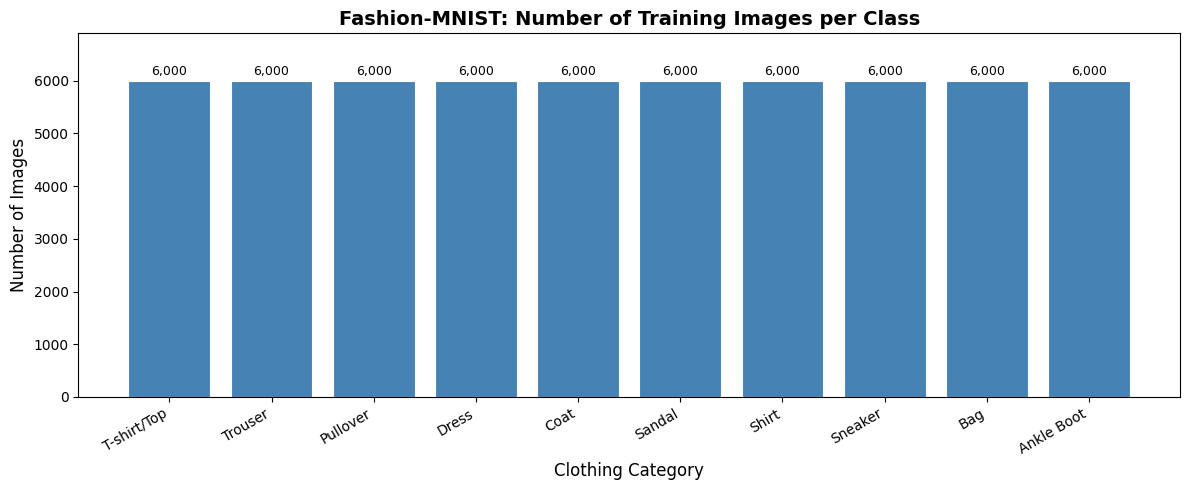


✅ All classes have exactly 6,000 images — perfectly balanced dataset!


In [4]:
# ── Count how many images exist per class ────────────────────────────────────
# train_set.targets is a tensor containing the label (0-9) for every training image
labels_array = train_set.targets.numpy()
class_counts = np.bincount(labels_array)   # Count occurrences of each label

print("📊 Training set — samples per class:")
print("-" * 35)
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    print(f"  Label {i} | {name:<15} | {count:,} images")

# ── Plot the class distribution as a bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, class_counts, color='steelblue', edgecolor='white', linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Fashion-MNIST: Number of Training Images per Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Clothing Category', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_ylim(0, max(class_counts) * 1.15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ All classes have exactly {class_counts[0]:,} images — perfectly balanced dataset!")

---

## Step 4: Visualising Sample Images

Now let's actually **look** at some of the images in our dataset. This is one of the most important steps — you should always visually inspect your data before training.

### What does the image look like at pixel level?

Remember, each image is just a **28 × 28 grid of numbers** (pixels). It's grayscale, meaning each pixel has a single value representing brightness — 0 is black, 255 is white (before normalisation).

When we display these images, our plotting library converts those numbers back into a visible picture.

### Why do we unnormalise?

When we loaded the data, we normalised pixel values from 0–1 to -1 to +1. For display purposes, we reverse this so the image looks correct visually (otherwise it would look washed out or oddly coloured).

**What to look for:** 10 rows of images, one row per clothing class. Each row should clearly show the category it represents.

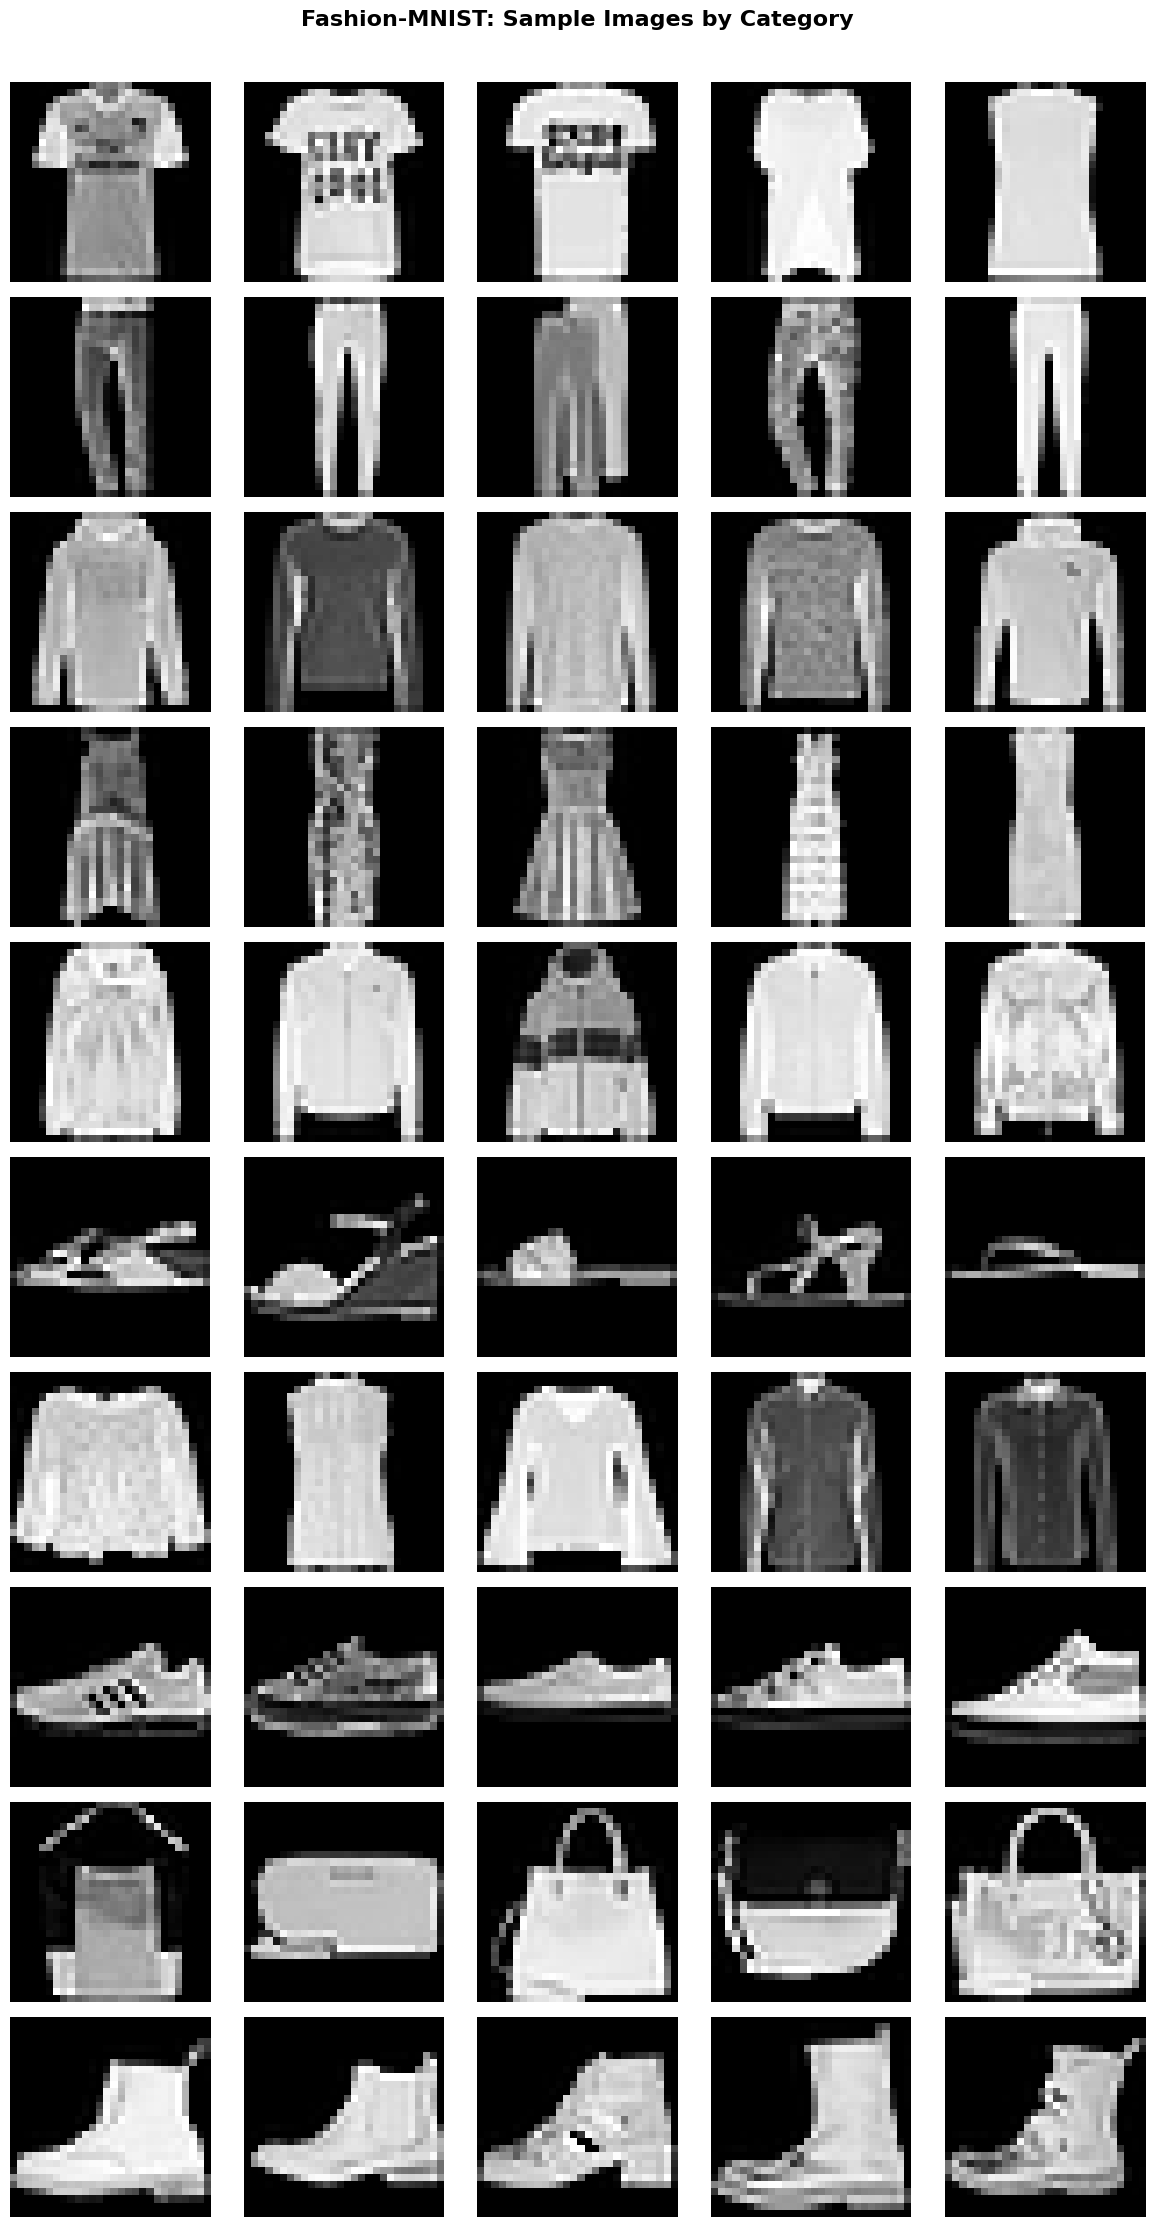

👆 Each row shows 5 random examples from one clothing category.
   Notice: some categories (e.g. Shirt vs Pullover) look very similar — a challenge for our model!


In [6]:
# ── Show 5 random examples from each of the 10 classes ───────────────────────
fig, axes = plt.subplots(10, 5, figsize=(12, 22))
fig.suptitle('Fashion-MNIST: Sample Images by Category', fontsize=16, fontweight='bold', y=1.01)

for class_idx in range(10):
    # Find indices of all images belonging to this class
    class_indices = np.where(labels_array == class_idx)[0]

    # Randomly pick 5 of them
    chosen = np.random.choice(class_indices, size=5, replace=False)

    for col, img_idx in enumerate(chosen):
        # Get the image and its label
        image, label = train_set[img_idx]

        # Unnormalise: reverse the transform (x * 0.5 + 0.5) to go back to 0–1
        image_display = image * 0.5 + 0.5   # Now pixels are in range 0 to 1

        ax = axes[class_idx][col]
        # squeeze() removes the channel dimension: shape [1,28,28] → [28,28]
        ax.imshow(image_display.squeeze(), cmap='gray')
        ax.axis('off')

        # Add class name label on the leftmost image of each row
        if col == 0:
            ax.set_ylabel(f"{class_idx}: {class_names[class_idx]}",
                          fontsize=9, rotation=0, labelpad=80, va='center')
            ax.yaxis.label.set_visible(True)

plt.tight_layout()
plt.show()

print("👆 Each row shows 5 random examples from one clothing category.")
print("   Notice: some categories (e.g. Shirt vs Pullover) look very similar — a challenge for our model!")

---

## Step 5: Zooming Into One Image — What Does a CNN Actually See?

Let's look at a single image in detail and understand what the raw pixel data looks like.

This helps us understand **why** a CNN is well-suited to this problem. A plain ANN (fully connected network) would treat each pixel as a single independent number, ignoring the spatial relationships between neighbouring pixels. A CNN, on the other hand, uses filters that slide across the image and detect **local patterns** — like edges, curves, textures — which are the building blocks of shapes.

**What to look for:** A single clothing item shown at different zoom levels, and its raw pixel grid displayed as a heatmap.

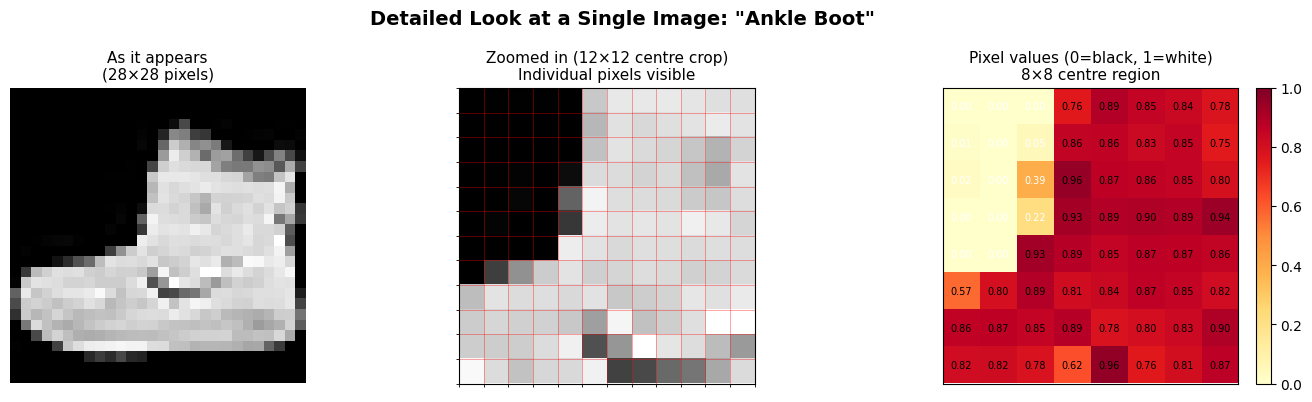


📐 Full image shape: torch.Size([1, 28, 28])  → [channels=1, height=28, width=28]
   Each image is a 28×28 grid of numbers (pixels).
   A CNN will scan across this grid using small filters to detect patterns.


In [7]:
# ── Pick a single sample image to inspect closely ────────────────────────────
sample_image, sample_label = train_set[0]
image_display = (sample_image * 0.5 + 0.5).squeeze().numpy()  # Shape: [28, 28], values 0–1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Detailed Look at a Single Image: "{class_names[sample_label]}"',
             fontsize=14, fontweight='bold')

# Plot 1: Normal view
axes[0].imshow(image_display, cmap='gray')
axes[0].set_title('As it appears\n(28×28 pixels)', fontsize=11)
axes[0].axis('off')

# Plot 2: Zoomed in with grid lines to see individual pixels
axes[1].imshow(image_display[8:20, 8:20], cmap='gray', interpolation='nearest')
axes[1].set_title('Zoomed in (12×12 centre crop)\nIndividual pixels visible', fontsize=11)
axes[1].set_xticks(np.arange(-0.5, 12, 1), minor=True)
axes[1].set_yticks(np.arange(-0.5, 12, 1), minor=True)
axes[1].grid(which='minor', color='red', linewidth=0.5, alpha=0.5)
axes[1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Plot 3: Pixel values as a heatmap with numbers
subset = image_display[10:18, 10:18]  # 8×8 region for readability
im = axes[2].imshow(subset, cmap='YlOrRd', vmin=0, vmax=1)
axes[2].set_title('Pixel values (0=black, 1=white)\n8×8 centre region', fontsize=11)
for i in range(8):
    for j in range(8):
        axes[2].text(j, i, f'{subset[i,j]:.2f}', ha='center', va='center',
                     fontsize=7, color='black' if subset[i,j] > 0.5 else 'white')
axes[2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"\n📐 Full image shape: {sample_image.shape}  → [channels=1, height=28, width=28]")
print(f"   Each image is a 28×28 grid of numbers (pixels).")
print(f"   A CNN will scan across this grid using small filters to detect patterns.")

---

## Step 6: Building Our CNN Model

Now for the heart of the notebook — designing the **Convolutional Neural Network**.

### Your mental model is correct! Here is how our CNN maps to what you already know:

```
INPUT IMAGE (28×28, 1 channel, grayscale)
       ↓
  ┌─────────────────────────────────────┐
  │  CONVOLUTIONAL BLOCK 1              │
  │  Conv → ReLU → MaxPool             │
  │  (Image gets smaller, but we       │
  │   detect low-level features:       │
  │   edges, curves, textures)         │
  └─────────────────────────────────────┘
       ↓
  ┌─────────────────────────────────────┐
  │  CONVOLUTIONAL BLOCK 2              │
  │  Conv → ReLU → MaxPool             │
  │  (Detect more complex patterns:    │
  │   sleeves, collars, soles)         │
  └─────────────────────────────────────┘
       ↓
  FLATTEN (turn 2D feature maps → 1D list of numbers)
       ↓
  ┌─────────────────────────────────────┐
  │  FULLY CONNECTED ANN                │
  │  Linear → ReLU → Dropout           │
  │  Linear → ReLU                     │
  │  Linear → (10 outputs)             │
  └─────────────────────────────────────┘
       ↓
  SOFTMAX → 10 probabilities (one per class)
  The class with the highest probability is our prediction!
```

### Explaining Every Parameter

**Convolutional Layer — `nn.Conv2d(in_channels, out_channels, kernel_size, padding)`**
- `in_channels`: How many channels does the incoming image/feature map have? Grayscale = 1 channel. Colour (RGB) = 3 channels.
- `out_channels`: How many filters are we applying? More filters = more patterns the layer can detect. Also called the number of **feature maps** output.
- `kernel_size`: The size of the filter (small window that slides over the image). A `3×3` kernel looks at a 3×3 patch of pixels at a time.
- `padding=1`: Adds a 1-pixel border of zeros around the image. Without this, the image shrinks after each convolution. With `padding=1` and a 3×3 kernel, the output stays the same size as the input.

**Activation — `nn.ReLU()`**
- ReLU stands for Rectified Linear Unit. It replaces any negative value with 0, and keeps positive values as-is.
- This introduces **non-linearity** — without it, stacking many layers would be mathematically equivalent to just one layer.

**Pooling — `nn.MaxPool2d(kernel_size=2, stride=2)`**
- Takes a 2×2 window, keeps the **maximum** value, and moves 2 steps (stride=2).
- This halves the height and width of the feature map (e.g., 28×28 → 14×14).
- Why? It **reduces the data size** (faster processing) and makes the model **robust to small shifts** in the image.

**Dropout — `nn.Dropout(0.5)`**
- Randomly switches off 50% of neurons during training. This sounds destructive, but it's very helpful!
- It forces the network to not rely too heavily on any single neuron — leading to better **generalisation** (good performance on unseen data).
- Dropout is only active during training; it's automatically switched off during evaluation.

**Fully Connected Layer — `nn.Linear(in_features, out_features)`**
- The classic ANN layer. Every input is connected to every output.
- `in_features`: Size of the flattened input vector.
- `out_features`: Number of neurons in this layer.

**Output Layer — `nn.Linear(128, 10)`**
- 10 outputs = one score (called a **logit**) for each of our 10 clothing classes.
- The class with the **highest score** is our model's prediction.
- Softmax converts these scores into **probabilities** (all add up to 1.0).

**What to look for:** The model summary should show you all layers in order, and the total number of learnable parameters.

In [8]:
class FashionCNN(nn.Module):
    """
    A Convolutional Neural Network for classifying Fashion-MNIST images.

    Architecture:
      Input  : (batch, 1, 28, 28)  — 1 grayscale channel, 28×28 pixels
      Block 1: Conv(32 filters) → ReLU → MaxPool  → (batch, 32, 14, 14)
      Block 2: Conv(64 filters) → ReLU → MaxPool  → (batch, 64,  7,  7)
      Flatten:                                      → (batch, 64×7×7 = 3136)
      FC 1   : Linear(3136 → 256) → ReLU → Dropout(0.5)
      FC 2   : Linear(256  → 128) → ReLU
      Output : Linear(128  →  10)           ← 10 class scores
    """

    def __init__(self):
        super(FashionCNN, self).__init__()

        # ──────────────────────────────────────────────────────────────────
        # CONVOLUTIONAL BLOCK 1
        # Input shape : (batch, 1, 28, 28)   — 1 input channel (grayscale)
        # After Conv  : (batch, 32, 28, 28)  — 32 feature maps, same size (padding=1)
        # After Pool  : (batch, 32, 14, 14)  — halved by MaxPool 2×2
        # ──────────────────────────────────────────────────────────────────
        self.conv1 = nn.Conv2d(
            in_channels=1,       # Input: 1 grayscale channel
            out_channels=32,     # Output: 32 feature maps (32 different filters applied)
            kernel_size=3,       # Each filter is a 3×3 window
            padding=1            # Zero-padding to keep output size same as input
        )
        self.relu1 = nn.ReLU()   # Activation: keep positive values, set negatives to 0
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,       # Look at 2×2 windows
            stride=2             # Move 2 pixels at a time → output is half the size
        )

        # ──────────────────────────────────────────────────────────────────
        # CONVOLUTIONAL BLOCK 2
        # Input shape : (batch, 32, 14, 14)  — 32 channels from block 1
        # After Conv  : (batch, 64, 14, 14)  — 64 feature maps, same size
        # After Pool  : (batch, 64,  7,  7)  — halved again
        # ──────────────────────────────────────────────────────────────────
        self.conv2 = nn.Conv2d(
            in_channels=32,      # Must match out_channels of previous layer
            out_channels=64,     # Now 64 feature maps — learning more complex patterns
            kernel_size=3,
            padding=1
        )
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ──────────────────────────────────────────────────────────────────
        # FLATTEN
        # After two MaxPool operations: 28 → 14 → 7
        # We have 64 feature maps, each 7×7
        # Flattened size = 64 × 7 × 7 = 3,136
        # ──────────────────────────────────────────────────────────────────
        self.flatten = nn.Flatten()   # Turns the 3D tensor into a 1D vector

        # ──────────────────────────────────────────────────────────────────
        # FULLY CONNECTED LAYERS (the ANN part)
        # ──────────────────────────────────────────────────────────────────
        self.fc1 = nn.Linear(
            in_features=64 * 7 * 7,  # = 3136 — the flattened feature vector
            out_features=256          # Compress into 256 neurons
        )
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)  # Randomly drop 50% of neurons during training

        self.fc2 = nn.Linear(256, 128)    # Further compress to 128 neurons
        self.relu4 = nn.ReLU()

        # ──────────────────────────────────────────────────────────────────
        # OUTPUT LAYER
        # 10 outputs = one score per clothing class
        # (Softmax is applied separately during evaluation)
        # ──────────────────────────────────────────────────────────────────
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        """
        forward() defines how data flows through the network.
        x is a batch of images with shape (batch_size, 1, 28, 28).
        """
        # Convolutional Block 1
        x = self.conv1(x)    # Apply 32 filters to the image
        x = self.relu1(x)    # Apply activation
        x = self.pool1(x)    # Downsample: 28×28 → 14×14

        # Convolutional Block 2
        x = self.conv2(x)    # Apply 64 filters to the 32 feature maps
        x = self.relu2(x)    # Apply activation
        x = self.pool2(x)    # Downsample: 14×14 → 7×7

        # Flatten: turn (batch, 64, 7, 7) → (batch, 3136)
        x = self.flatten(x)

        # Fully connected layers
        x = self.fc1(x)      # 3136 → 256
        x = self.relu3(x)
        x = self.dropout(x)  # Regularisation — active only during training

        x = self.fc2(x)      # 256 → 128
        x = self.relu4(x)

        x = self.output(x)   # 128 → 10 class scores (logits)
        return x


# ── Instantiate the model and move it to the available device ────────────────
model = FashionCNN().to(device)

# ── Print a summary ───────────────────────────────────────────────────────────
print("🧠 CNN Architecture:")
print("=" * 55)
print(model)
print("=" * 55)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🔢 Total trainable parameters: {total_params:,}")
print("   These are the 'weights' and 'biases' the model learns during training.")

🧠 CNN Architecture:
FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu4): ReLU()
  (output): Linear(in_features=128, out_features=10, bias=True)
)

🔢 Total trainable parameters: 856,074
   These are the 'weights' and 'biases' the model learns during training.


---

## Step 7: Setting Up the Loss Function and Optimiser

Before training, we need two more things:

### 1. Loss Function — `CrossEntropyLoss`

The **loss function** measures *how wrong* the model is. It takes the model's prediction and the correct label, and outputs a single number — the **loss**. The lower the loss, the better.

We use **CrossEntropyLoss**, which is the standard choice for **multi-class classification** (when there are more than 2 classes). It works well with Softmax and penalises confident wrong answers more harshly.

Think of it like a penalty score in a quiz: if you say "I'm 99% sure it's a T-shirt" but it's actually a coat, you get a much bigger penalty than if you were unsure.

### 2. Optimiser — `Adam`

The **optimiser** is the algorithm that adjusts the model's weights based on the loss. It figures out *in which direction* and *by how much* to change each weight.

We use **Adam** (Adaptive Moment Estimation) — one of the most popular optimisers because it:
- Adapts the learning rate individually for each parameter
- Usually trains faster than basic gradient descent
- Works well without needing careful tuning

### Learning Rate (`lr=0.001`)

The **learning rate** controls how big a step the optimiser takes when adjusting weights.
- Too **large**: Training becomes unstable and the model oscillates or diverges
- Too **small**: Training works but takes very long
- `0.001` is a widely used default that works well for most problems

**What to look for:** No errors — just a confirmation that loss and optimiser are set up.

In [11]:
# ── Loss Function ─────────────────────────────────────────────────────────────
# CrossEntropyLoss is the standard for multi-class classification.
# It combines LogSoftmax + NLLLoss internally, so we do NOT need to apply
# softmax ourselves during training.
criterion = nn.CrossEntropyLoss()

# ── Optimiser ─────────────────────────────────────────────────────────────────
# Adam adjusts weights based on the gradient of the loss function.
# model.parameters() passes all the learnable weights to the optimiser.
# lr = learning rate: step size for each weight update
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Learning Rate Scheduler (optional but good practice) ─────────────────────
# If the model stops improving, we can reduce the learning rate automatically.
# ReduceLROnPlateau: if validation accuracy doesn't improve for 3 epochs,
# multiply the learning rate by 0.5 (halve it) to help fine-tune the model.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        # We want to MAXIMISE accuracy
    patience=3,        # Wait 3 epochs with no improvement before reducing LR
    factor=0.5         # Multiply LR by 0.5 when triggered
)

print("✅ Loss function: CrossEntropyLoss")
print("✅ Optimiser    : Adam (learning rate = 0.001)")
print("✅ LR Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)")

✅ Loss function: CrossEntropyLoss
✅ Optimiser    : Adam (learning rate = 0.001)
✅ LR Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)


---

## Step 8: Training the Model

This is where the model **actually learns**. Training involves repeating the following cycle many times:

### The Training Loop — One Epoch:

```
For each batch of 64 images:
  1. Forward pass  → model makes predictions
  2. Compute loss  → how wrong were the predictions?
  3. Backward pass → calculate gradients (which direction to move each weight)
  4. Update weights → take a small step in the right direction (via optimiser)
  5. Repeat
```

An **epoch** = one full pass through all 60,000 training images.

### What is a gradient?

A gradient is essentially the slope of the loss curve with respect to each weight. If the gradient is large, the weight has a big impact on the loss. The optimiser uses gradients to figure out how to change each weight to reduce the loss. This process is called **backpropagation**.

### Training vs Validation

After each epoch of training, we test the model on the **test set** (data it has never been trained on). This tells us:
- **Training accuracy**: How well it performs on data it has seen
- **Test accuracy**: How well it generalises to new data

If training accuracy is much higher than test accuracy, the model is **overfitting** (memorising rather than learning).

**What to look for:** Both loss (training) and accuracy (test) should steadily improve with each epoch.

In [12]:
# ── Training configuration ────────────────────────────────────────────────────
NUM_EPOCHS = 15   # How many times to go through the full training set
                  # More epochs = more training, but risk of overfitting

# ── Lists to store history for plotting later ─────────────────────────────────
train_losses = []
test_accuracies = []
train_accuracies = []

print(f"🚀 Starting training for {NUM_EPOCHS} epochs...")
print(f"   Training on {len(train_set):,} images, evaluating on {len(test_set):,} images")
print("=" * 70)
print(f"{'Epoch':^6} | {'Train Loss':^12} | {'Train Acc':^12} | {'Test Acc':^12} | {'LR':^10}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── TRAINING PHASE ────────────────────────────────────────────────────────
    model.train()   # Set model to training mode (enables Dropout etc.)
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Move data to the same device as the model (GPU or CPU)
        images, labels = images.to(device), labels.to(device)

        # Step 1: Zero the gradients from the previous batch
        # (If we don't do this, gradients accumulate across batches — wrong!)
        optimizer.zero_grad()

        # Step 2: Forward pass — get model predictions (raw scores / logits)
        outputs = model(images)   # Shape: (64, 10) — 64 images, 10 class scores each

        # Step 3: Compute the loss
        loss = criterion(outputs, labels)

        # Step 4: Backward pass — compute gradients
        loss.backward()

        # Step 5: Update weights using the computed gradients
        optimizer.step()

        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  # Get the class with highest score
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct_train / total_train

    # ── EVALUATION PHASE ──────────────────────────────────────────────────────
    model.eval()    # Set model to evaluation mode (disables Dropout)
    correct_test = 0
    total_test = 0

    with torch.no_grad():   # Don't compute gradients during evaluation (saves memory)
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    test_acc = 100.0 * correct_test / total_test

    # Update learning rate scheduler based on test accuracy
    scheduler.step(test_acc)
    current_lr = optimizer.param_groups[0]['lr']

    # Store for plotting
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"  {epoch:^4}   | {avg_train_loss:^12.4f} | {train_acc:^11.2f}% | {test_acc:^11.2f}% | {current_lr:^10.6f}")

print("=" * 70)
print(f"\n🏁 Training complete!")
print(f"   Best test accuracy: {max(test_accuracies):.2f}%  (Epoch {test_accuracies.index(max(test_accuracies)) + 1})")

🚀 Starting training for 15 epochs...
   Training on 60,000 images, evaluating on 10,000 images
Epoch  |  Train Loss  |  Train Acc   |   Test Acc   |     LR    
----------------------------------------------------------------------
   1     |    0.5435    |    79.98   % |    87.08   % |  0.001000 
   2     |    0.3489    |    87.60   % |    88.82   % |  0.001000 
   3     |    0.2940    |    89.43   % |    90.13   % |  0.001000 
   4     |    0.2585    |    90.69   % |    90.63   % |  0.001000 
   5     |    0.2347    |    91.42   % |    91.28   % |  0.001000 
   6     |    0.2143    |    92.14   % |    91.54   % |  0.001000 
   7     |    0.1990    |    92.67   % |    91.17   % |  0.001000 
   8     |    0.1839    |    93.30   % |    91.81   % |  0.001000 
   9     |    0.1738    |    93.56   % |    92.01   % |  0.001000 
   10    |    0.1595    |    94.13   % |    91.68   % |  0.001000 
   11    |    0.1496    |    94.55   % |    92.18   % |  0.001000 
   12    |    0.1400    |    94.

---

## Step 9: Visualising the Training Progress

Now let's plot how our model improved over the training epochs.

These plots are crucial for understanding if:
- The model is **learning** (both loss decreasing, accuracy increasing)
- The model is **overfitting** (training accuracy much higher than test accuracy)
- Training has **converged** (curves have plateaued and stopped improving)

**What to look for:**
- **Left chart (Loss)**: Should go down and flatten out
- **Right chart (Accuracy)**: Both lines should go up; training and test should be close together

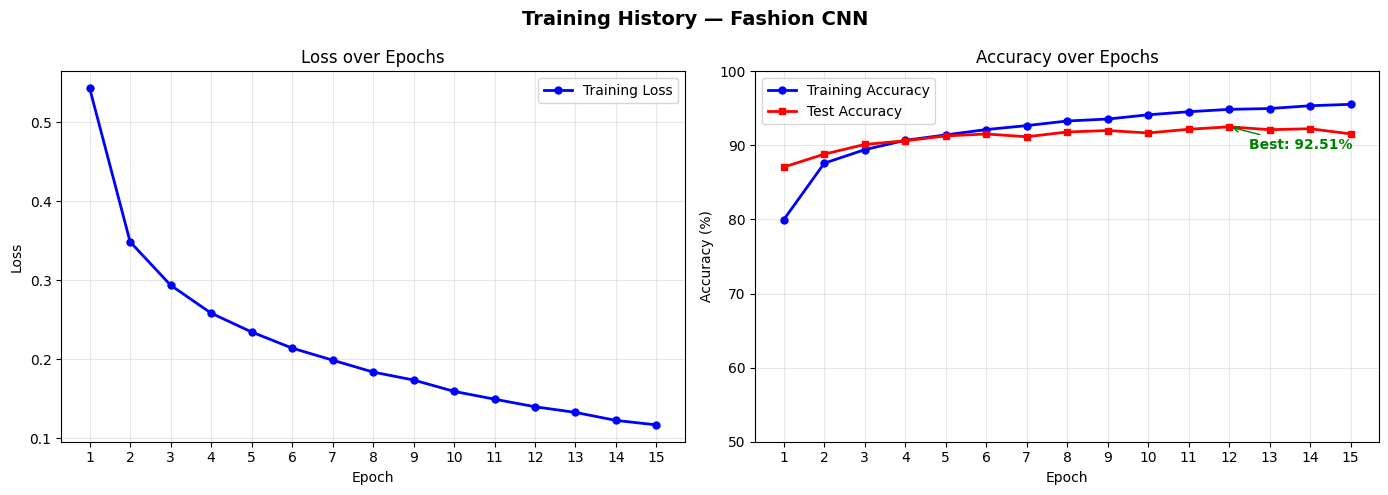

📈 Training Summary:
   Initial test accuracy : 87.08%
   Final test accuracy   : 91.55%
   Best test accuracy    : 92.51%  (Epoch 12)
   Final training accuracy: 95.55%
   Overfitting gap       : 4.00%  (small gap = good generalisation ✅)


In [13]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Fashion CNN', fontsize=14, fontweight='bold')

# ── Plot 1: Training Loss ─────────────────────────────────────────────────────
ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=5, label='Training Loss')
ax1.set_title('Loss over Epochs', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# ── Plot 2: Accuracy (Training vs Test) ───────────────────────────────────────
ax2.plot(epochs_range, train_accuracies, 'b-o', linewidth=2, markersize=5, label='Training Accuracy')
ax2.plot(epochs_range, test_accuracies,  'r-s', linewidth=2, markersize=5, label='Test Accuracy')
ax2.set_title('Accuracy over Epochs', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim(50, 100)

# Mark the best test accuracy
best_epoch = test_accuracies.index(max(test_accuracies)) + 1
best_acc = max(test_accuracies)
ax2.annotate(f'Best: {best_acc:.2f}%',
             xy=(best_epoch, best_acc),
             xytext=(best_epoch + 0.5, best_acc - 3),
             arrowprops=dict(arrowstyle='->', color='green'),
             color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📈 Training Summary:")
print(f"   Initial test accuracy : {test_accuracies[0]:.2f}%")
print(f"   Final test accuracy   : {test_accuracies[-1]:.2f}%")
print(f"   Best test accuracy    : {best_acc:.2f}%  (Epoch {best_epoch})")
print(f"   Final training accuracy: {train_accuracies[-1]:.2f}%")
gap = train_accuracies[-1] - test_accuracies[-1]
print(f"   Overfitting gap       : {gap:.2f}%  ", end="")
print("(small gap = good generalisation ✅)" if gap < 5 else "(large gap may indicate overfitting ⚠️)")

---

## Step 10: Evaluating the Model — Confusion Matrix

Accuracy alone doesn't tell the full story. A **confusion matrix** shows us *which* classes the model confuses with each other.

### How to read a confusion matrix:
- **Rows** = actual (true) class
- **Columns** = predicted class
- **Diagonal** (top-left to bottom-right) = correct predictions
- **Off-diagonal** values = mistakes

For example, if row 2 (Pullover) and column 6 (Shirt) has a high number, it means the model often mistakes Pullovers for Shirts — which is understandable given how similar they look!

**What to look for:** A bright diagonal with dark off-diagonal values means the model is performing well.

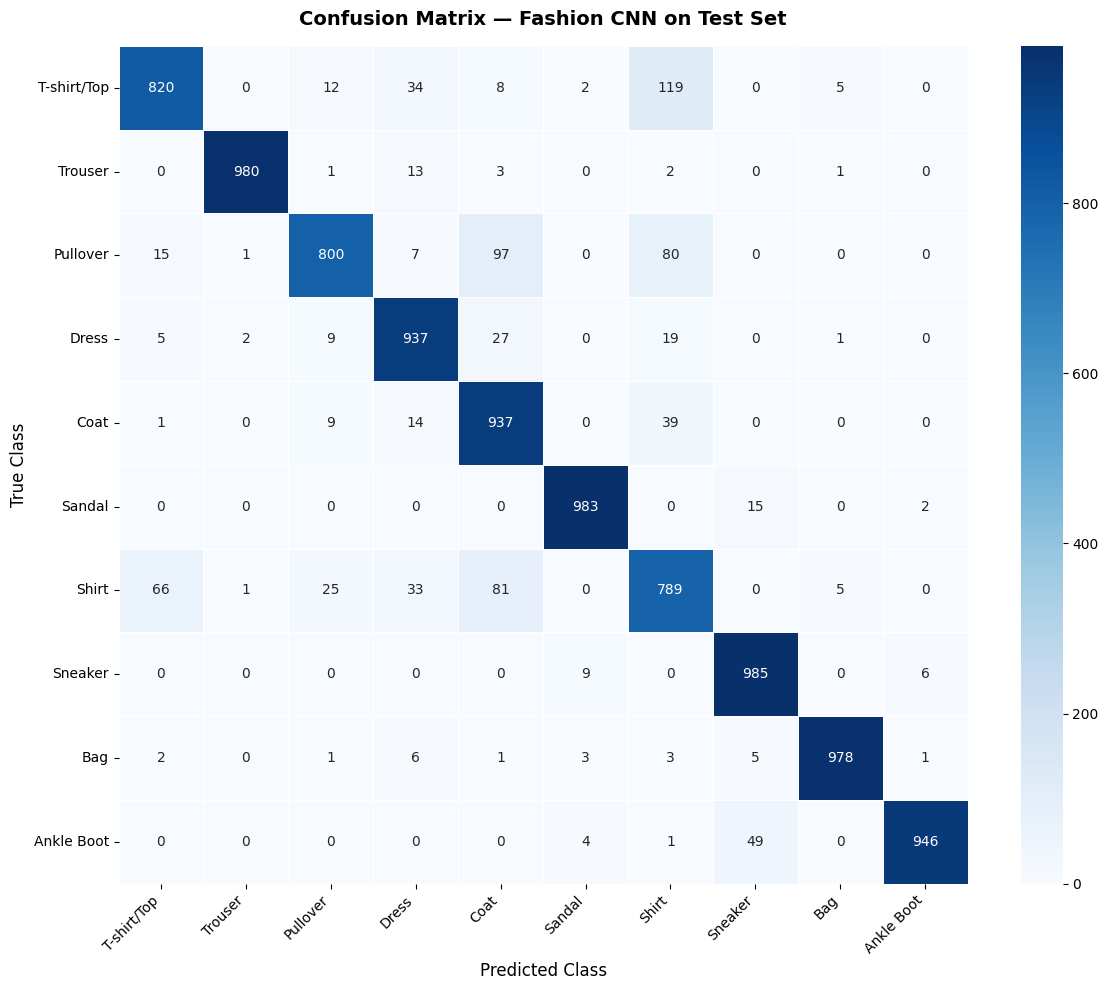


📊 Per-class Accuracy:
----------------------------------------
  T-shirt/Top    :  82.0%  ████████████████
  Trouser        :  98.0%  ███████████████████
  Pullover       :  80.0%  ████████████████
  Dress          :  93.7%  ██████████████████
  Coat           :  93.7%  ██████████████████
  Sandal         :  98.3%  ███████████████████
  Shirt          :  78.9%  ███████████████
  Sneaker        :  98.5%  ███████████████████
  Bag            :  97.8%  ███████████████████
  Ankle Boot     :  94.6%  ██████████████████


In [14]:
# ── Collect all predictions and true labels ───────────────────────────────────
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Compute confusion matrix ──────────────────────────────────────────────────
cm_matrix = confusion_matrix(all_labels, all_preds)

# ── Plot confusion matrix ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_matrix,
    annot=True,              # Show numbers in each cell
    fmt='d',                 # Format as integer
    cmap='Blues',            # Colour scheme
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
ax.set_title('Confusion Matrix — Fashion CNN on Test Set', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class accuracy ────────────────────────────────────────────────────────
print("\n📊 Per-class Accuracy:")
print("-" * 40)
for i in range(10):
    class_correct = cm_matrix[i, i]
    class_total = cm_matrix[i, :].sum()
    acc = 100 * class_correct / class_total
    bar = '█' * int(acc / 5)
    print(f"  {class_names[i]:<15}: {acc:5.1f}%  {bar}")

---

## Step 11: Detailed Classification Report

Let's get a full breakdown of performance metrics per class.

### Key Metrics Explained:

- **Precision**: Of all the times the model predicted "Shirt", how often was it actually a Shirt? (Avoids false positives)
- **Recall**: Of all the actual Shirts in the dataset, how many did the model correctly find? (Avoids false negatives)
- **F1-Score**: A combined measure of precision and recall. Useful when classes have different importance.
- **Support**: How many images of this class are in the test set.

In [15]:
report = classification_report(all_labels, all_preds, target_names=class_names)
print("📋 Full Classification Report:")
print("=" * 65)
print(report)
print("=" * 65)
print("\n💡 Key observations:")
print("   - Which class has the lowest F1-score? That is where the model struggles most.")
print("   - Classes that look visually similar (e.g. Shirt, Pullover, Coat) tend to be confused.")
print("   - Classes with distinctive shapes (e.g. Trouser, Bag) tend to have high scores.")

📋 Full Classification Report:
              precision    recall  f1-score   support

 T-shirt/Top       0.90      0.82      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.93      0.80      0.86      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.81      0.94      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.79      0.77      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle Boot       0.99      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


💡 Key observations:
   - Which class has the lowest F1-score? That is where the model struggles most.
   - Classes that look visually similar (e.g. Shirt, Pullover, Coat) tend to be confused.
   - Classes with 

---

## Step 12: Visualising Predictions — Where Does It Succeed and Fail?

Numbers are informative, but seeing the actual images the model gets wrong is very revealing.

We'll show:
1. **Correct predictions** — what the model gets right
2. **Wrong predictions** — images it misclassifies, and what it thought they were

This kind of visual inspection is essential in AI development — it helps you understand the model's limitations and think about how to improve it.

**What to look for:** Correct predictions should look clearly like their class. Wrong predictions will often be genuinely ambiguous images — even humans might struggle!

/tmp/ipykernel_6179/3103517641.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


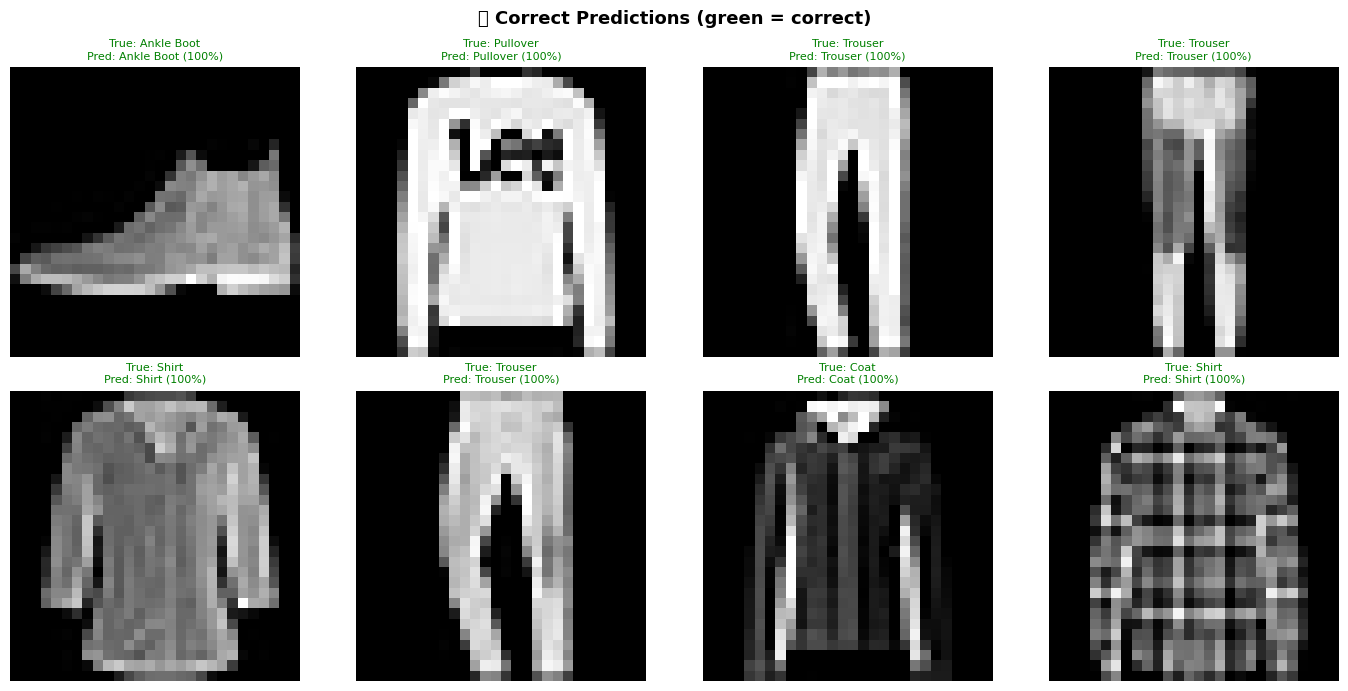

/tmp/ipykernel_6179/3103517641.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


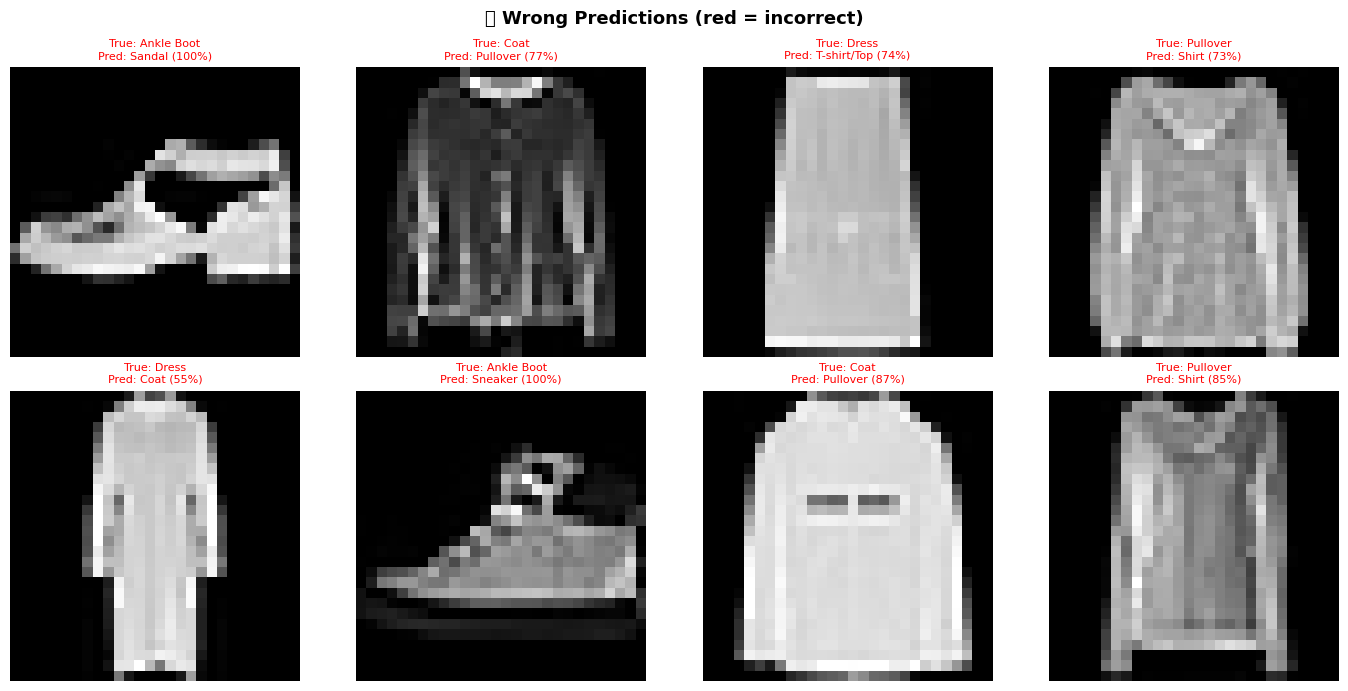


📌 Of the first 200 test images sampled:
   Correct: 240   Wrong: 16
   Notice how 'wrong' images are often genuinely ambiguous — even to a human eye!


In [16]:
# ── Gather individual test image predictions for display ──────────────────────
model.eval()
sample_images_list = []
sample_true_list = []
sample_pred_list = []
sample_conf_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        # Apply softmax to get probabilities from raw scores
        probs = torch.softmax(outputs, dim=1)
        conf, predicted = torch.max(probs, 1)

        sample_images_list.extend(images.cpu())
        sample_true_list.extend(labels.numpy())
        sample_pred_list.extend(predicted.cpu().numpy())
        sample_conf_list.extend(conf.cpu().numpy())

        if len(sample_images_list) >= 200:
            break

# ── Find correct and incorrect predictions ────────────────────────────────────
correct_idx = [i for i in range(len(sample_pred_list))
               if sample_pred_list[i] == sample_true_list[i]]
wrong_idx   = [i for i in range(len(sample_pred_list))
               if sample_pred_list[i] != sample_true_list[i]]

def show_predictions(indices, title, n=8):
    chosen = indices[:n]
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i, idx in enumerate(chosen):
        ax = axes[i // 4][i % 4]
        img = sample_images_list[idx] * 0.5 + 0.5  # Unnormalise
        ax.imshow(img.squeeze(), cmap='gray')
        true_name = class_names[sample_true_list[idx]]
        pred_name = class_names[sample_pred_list[idx]]
        conf_val  = sample_conf_list[idx] * 100
        colour = 'green' if true_name == pred_name else 'red'
        ax.set_title(f"True: {true_name}\nPred: {pred_name} ({conf_val:.0f}%)",
                     fontsize=8, color=colour)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(correct_idx[:8], '✅ Correct Predictions (green = correct)')
show_predictions(wrong_idx[:8],   '❌ Wrong Predictions (red = incorrect)')

print(f"\n📌 Of the first 200 test images sampled:")
print(f"   Correct: {len(correct_idx)}   Wrong: {len(wrong_idx)}")
print(f"   Notice how 'wrong' images are often genuinely ambiguous — even to a human eye!")

---

## Step 13: Testing on Completely Unseen Data

This is the final and most important test — a **real-world simulation**.

We pick random individual images from the test set that the model has **never been trained on**, run them through the model one at a time, and see the model's prediction along with the **probability distribution** across all 10 classes.

This simulates how the model would be used in production — a new image arrives, and the model instantly classifies it and tells you how confident it is.

### Reading the probability bar chart:
- **Tall bar** at one class = model is confident about that prediction
- **Multiple tall bars** = model is uncertain between classes — a sign the image is ambiguous

**What to look for:** For clear items like trousers or bags, the model should show one very tall bar. For ambiguous items like shirts vs pullovers, you may see multiple bars.

🔍 Testing on individual unseen images from the test set...
   (These images were NOT used in training — a true test of generalisation)



/tmp/ipykernel_6179/2073496422.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


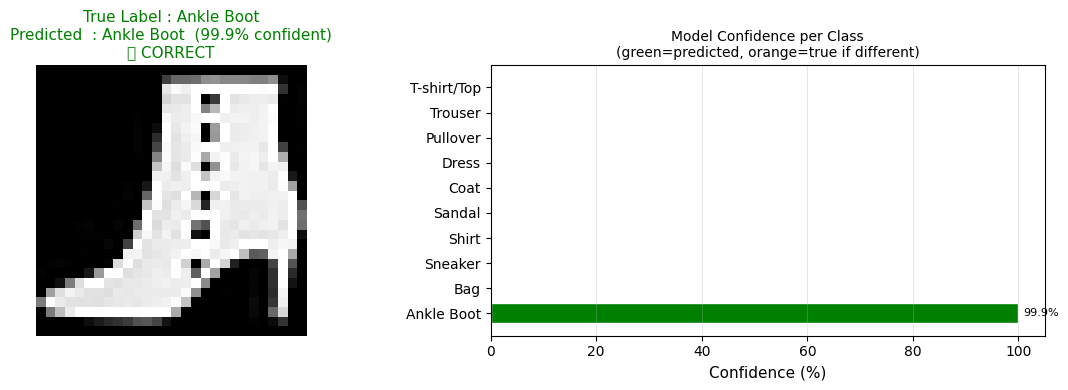

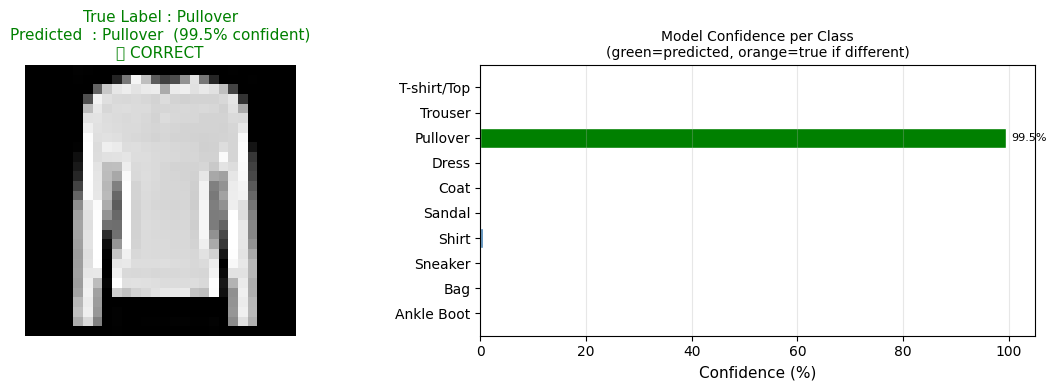

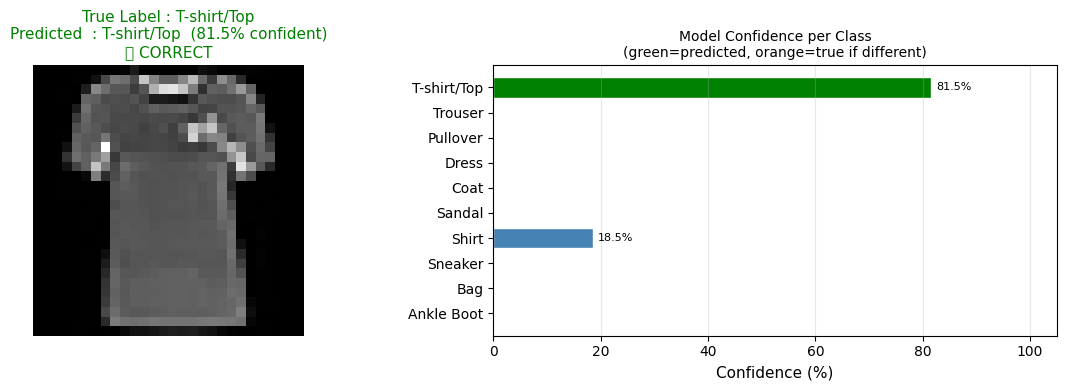

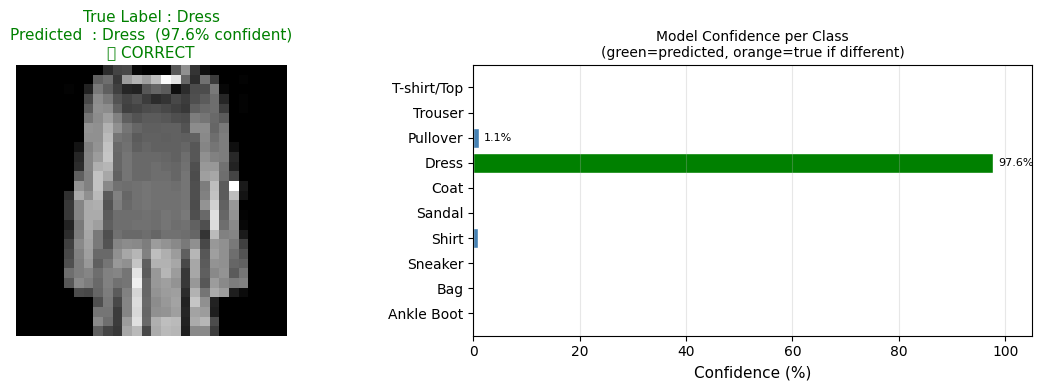

In [17]:
def predict_single_image(image_tensor, true_label):
    """
    Run one image through the trained model and display:
    - The image itself
    - The model's predicted class and confidence
    - The full probability distribution across all 10 classes
    """
    model.eval()

    # Add a batch dimension: [1, 28, 28] → [1, 1, 28, 28]
    # Neural networks always expect input in batches, even for a single image
    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)            # Raw scores (logits)
        probs  = torch.softmax(output, dim=1)   # Convert to probabilities
        confidence, predicted_class = torch.max(probs, 1)

    probs_np = probs.squeeze().cpu().numpy()
    pred_idx = predicted_class.item()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ── Left: Show the image ─────────────────────────────────────────────────
    img_display = (image_tensor * 0.5 + 0.5).squeeze().numpy()
    ax1.imshow(img_display, cmap='gray')
    correct = (pred_idx == true_label)
    colour = 'green' if correct else 'red'
    ax1.set_title(
        f"True Label : {class_names[true_label]}\n"
        f"Predicted  : {class_names[pred_idx]}  ({confidence.item()*100:.1f}% confident)\n"
        f"{'✅ CORRECT' if correct else '❌ WRONG'}",
        fontsize=11, color=colour
    )
    ax1.axis('off')

    # ── Right: Show probability distribution ─────────────────────────────────
    bar_colours = ['green' if i == pred_idx else
                   'orange' if i == true_label else 'steelblue'
                   for i in range(10)]
    bars = ax2.barh(class_names, probs_np * 100, color=bar_colours, edgecolor='white')
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Model Confidence per Class\n(green=predicted, orange=true if different)', fontsize=10)
    ax2.set_xlim(0, 105)
    for bar, prob in zip(bars, probs_np):
        if prob > 0.01:
            ax2.text(prob * 100 + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=8)
    ax2.invert_yaxis()  # Match class order with left plot
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Test on 4 random unseen images ────────────────────────────────────────────
print("🔍 Testing on individual unseen images from the test set...")
print("   (These images were NOT used in training — a true test of generalisation)\n")

# Pick 4 random test images
random_indices = np.random.choice(len(test_set), size=4, replace=False)
for idx in random_indices:
    image, label = test_set[idx]
    predict_single_image(image, label)

---

## Step 14: Saving the Trained Model

After training, it's good practice to **save the model weights** so you don't have to retrain from scratch every time.

We save the model's **state dict** — this is a dictionary containing all the learned weights and biases. Later, we can load this file and the model is ready to use immediately.

This is how production AI systems work — you train once (possibly for days on a powerful machine), then deploy the saved model to a server where it can respond to requests instantly.

In [18]:
# ── Save the model ────────────────────────────────────────────────────────────
model_save_path = 'fashion_cnn_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"✅ Model saved to: {model_save_path}")
print(f"   File size: {__import__('os').path.getsize(model_save_path) / 1024:.1f} KB")

# ── Demonstrate loading the model ─────────────────────────────────────────────
# This shows how to restore the model later
loaded_model = FashionCNN().to(device)
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.eval()
print(f"\n✅ Model successfully loaded and ready for inference!")
print(f"   You can now use 'loaded_model' to make predictions without retraining.")

✅ Model saved to: fashion_cnn_model.pth
   File size: 3348.4 KB

✅ Model successfully loaded and ready for inference!
   You can now use 'loaded_model' to make predictions without retraining.


---

## Step 15: Final Summary — What We Built and What It Means

Let's recap the full journey.

In [19]:
final_test_acc = test_accuracies[-1]
best_test_acc  = max(test_accuracies)

print("=" * 65)
print("  FASHION-MNIST CNN — FINAL SUMMARY")
print("=" * 65)
print(f"""
📌 Business Problem:
   Automatic clothing image classification for e-commerce
   (IntelliSys Ltd. — Digital Media / Retail Sector)

📦 Dataset:
   Fashion-MNIST — 70,000 grayscale images, 10 clothing classes
   Training: 60,000 images  |  Test: 10,000 images

🧠 Model Architecture:
   CNN with 2 convolutional blocks + 3 fully connected layers
   Total parameters: {total_params:,}

   Image (28×28)
   → Conv(32) + ReLU + MaxPool → 14×14
   → Conv(64) + ReLU + MaxPool → 7×7
   → Flatten → FC(256) + Dropout → FC(128) → Output(10)
   → Softmax → Predicted class

📈 Training:
   Epochs: {NUM_EPOCHS}  |  Batch size: 64  |  Optimiser: Adam (lr=0.001)
   Loss function: CrossEntropyLoss

🏆 Results:
   Final test accuracy : {final_test_acc:.2f}%
   Best test accuracy  : {best_test_acc:.2f}%
   Random baseline     : 10.00%  (10 classes, random guessing)
   Improvement over baseline: {best_test_acc - 10:.1f} percentage points

💼 Business Value:
   A model with ~{best_test_acc:.0f}% accuracy means that out of every
   100 product images uploaded, it correctly classifies ~{best_test_acc:.0f}.
   This replaces hours of manual labelling with instant automated tagging,
   reducing cost and human error.

⚠️  Limitations & Future Work:
   - Model sometimes confuses visually similar classes (Shirt/Pullover/Coat)
   - Images are small (28×28) — real product images are much larger
   - Could explore: data augmentation, deeper architectures, transfer learning
   - Interpretability: Grad-CAM could show which pixels the model focuses on
""")
print("=" * 65)

  FASHION-MNIST CNN — FINAL SUMMARY

📌 Business Problem:
   Automatic clothing image classification for e-commerce
   (IntelliSys Ltd. — Digital Media / Retail Sector)

📦 Dataset:
   Fashion-MNIST — 70,000 grayscale images, 10 clothing classes
   Training: 60,000 images  |  Test: 10,000 images

🧠 Model Architecture:
   CNN with 2 convolutional blocks + 3 fully connected layers
   Total parameters: 856,074

   Image (28×28) 
   → Conv(32) + ReLU + MaxPool → 14×14
   → Conv(64) + ReLU + MaxPool → 7×7
   → Flatten → FC(256) + Dropout → FC(128) → Output(10)
   → Softmax → Predicted class

📈 Training:
   Epochs: 15  |  Batch size: 64  |  Optimiser: Adam (lr=0.001)
   Loss function: CrossEntropyLoss

🏆 Results:
   Final test accuracy : 91.55%
   Best test accuracy  : 92.51%
   Random baseline     : 10.00%  (10 classes, random guessing)
   Improvement over baseline: 82.5 percentage points

💼 Business Value:
   A model with ~93% accuracy means that out of every
   100 product images uploaded, 

---

## 📚 References

- Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278–2324.
- Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980.
- PyTorch Documentation: https://pytorch.org/docs/stable/index.html
- Torchvision Datasets: https://pytorch.org/vision/stable/datasets.html

---

*Notebook created for WM9B7 AI & Deep Learning Group Assessment, WMG University of Warwick 2025/26*